# **Forecasting in a Post-Pandemic World: A Guide to Modeling Shocks with Prophet**

Traditional tutorials mainly focus on exploring simple time series by fitting a smooth trend and consistent seasonal patterns. But what happens when a sudden, massive event like the COVID-19 pandemic shatters those assumptions? This tutorial tackles a more complex, predictive question: **How can we build a reliable forecast model when there is a fundamental "shock" in the time series analysis?**

This is a **time series forecasting** task under **structural breaks**. We will train a **Prophet** model to learn the new, evolving patterns in data disrupted by the pandemic. The model will learn to distinguish between the underlying, long-term trend, recurring seasonal patterns, and the powerful but temporary effects of events like lockdowns. Once trained, this model can produce more realistic forecasts, giving us a powerful tool to navigate post-pandemic uncertainty.

For this task, we will apply **Python** and Meta's [**Prophet**](https://github.com/facebook/prophet) library to build and train a robust time series models with the following steps:

* **Prepare a time series for shock modeling**, including identifying and defining anomalous periods.
* Construct a robust forecasting model using **Prophet**.
* Implement a **Generalized Additive Model (GAM)** that separates trend, seasonality, and one-off events.
* **Train a Prophet model** to distinguish between long-term patterns and event-driven shocks.
* **Evaluate the model's components** to gain insights into behavioral changes.
* Apply the trained model to **forecast patterns** in a dynamic environment.

**Credits**

This tutorial is adapted from the official [Prophet documentation](https://facebook.github.io/prophet/docs/handling_shocks.html).

The dataset is an aggregated version of the Pedestrian Counting System data provided by the **City of Melbourne**. The specific CSV file used in this tutorial is generously hosted by the Prophet team in their [examples repository](https://github.com/facebook/prophet/tree/master/examples).

**Compatibility**

This tutorial uses a small dataset and standard Python libraries, making it compatible with most environments.

| Platform | Compatible | Recommended | Notes |
| :--- | :---: | :---: | :--- |
| **Local (e.g., MacBook/PC)** | ✅ Yes | ✅ Yes | Perfect for learning. The dataset is small and runs instantly. |
| **Google Colab** | ✅ Yes | ✅ Yes | An excellent, hassle-free option. May require installing Prophet at the beginning of the session: `pip install prophet`. |
| **Midway Login Nodes** | ✅ Yes | ✅ Yes | Works well. May require installing Prophet at the beginning of the session: `pip install prophet`. |
| **Midway Compute Nodes** | ✅ Yes | ✅ Yes | Works well. May require installing Prophet at the beginning of the session: `pip install prophet`. |

## The Prophet Model: A Quick Primer

Before we dive in, it's helpful to know how Prophet works. At its core, Prophet is a **Generalized Additive Model (GAM)**, which represents a time series `y(t)` as a combination of several components:

$$y(t) = g(t) + s(t) + h(t) + \epsilon_t$$

  * `g(t)`: The **trend** function, which models non-periodic changes (i.e., overall growth or decline).
  * `s(t)`: The **seasonality** function, which models periodic changes (e.g., weekly, yearly patterns).
  * `h(t)`: The **holidays** function, which models the effects of special, one-off events.
  * `\epsilon_t`: The **error term**, representing random noise that the model can't explain.

Our goal throughout this tutorial is to correctly assign the patterns in our data to the right component.


## 1\. Setup and Data Exploration

First, let's set up our environment and load the dataset. The data, provided by the City of Melbourne, tracks daily pedestrian counts from a single sensor and is an appropriate resource for this task.

In [ ]:
# Install prophet on the login node before moving forward
%pip install prophet==1.1.7
# Downgrade cmdstanpy if needed: https://github.com/facebook/prophet/issues/2462#issuecomment-3427116408
%pip install cmdstanpy==1.2.5

In [ ]:
# Import libraries
%matplotlib inline
import os
import logging
import warnings

import pandas as pd
from prophet import Prophet
from matplotlib import pyplot as plt

In [ ]:
# Configure settings for cleaner output
logging.getLogger('prophet').setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
!mkdir ./pedestrians_covid
!wget https://github.com/facebook/prophet/raw/refs/heads/main/examples/example_pedestrians_covid.csv
!mv example_pedestrians_covid.csv ./pedestrians_covid

mkdir: cannot create directory ‘./pedestrians_covid’: File exists
--2025-11-01 14:50:37--  https://github.com/facebook/prophet/raw/refs/heads/main/examples/example_pedestrians_covid.csv
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/facebook/prophet/refs/heads/main/examples/example_pedestrians_covid.csv [following]
--2025-11-01 14:50:37--  https://raw.githubusercontent.com/facebook/prophet/refs/heads/main/examples/example_pedestrians_covid.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 25136 (25K) [text/plain]
Saving to: ‘example_pedestrians_covid.csv’

example_pedestrians 100%[===========

In [ ]:
DATA_DIR = "./pedestrians_covid"

In [ ]:
# Load the dataset from the official Prophet GitHub repository
file_path = os.path.join(DATA_DIR, "example_pedestrians_covid.csv")
df = pd.read_csv(file_path)

# Prophet requires columns to be named 'ds' (datestamp) and 'y' (value)
df.head()

,ds,y
0,2017-06-02,39230
1,2017-06-03,35290
2,2017-06-04,27083
3,2017-06-05,28727
4,2017-06-06,30315


Let's visualize the series to understand the challenge ahead.

<Axes: title={'center': 'Melbourne Pedestrian Counts (Sensor 4)'}, xlabel='Date', ylabel='Pedestrian Count'>

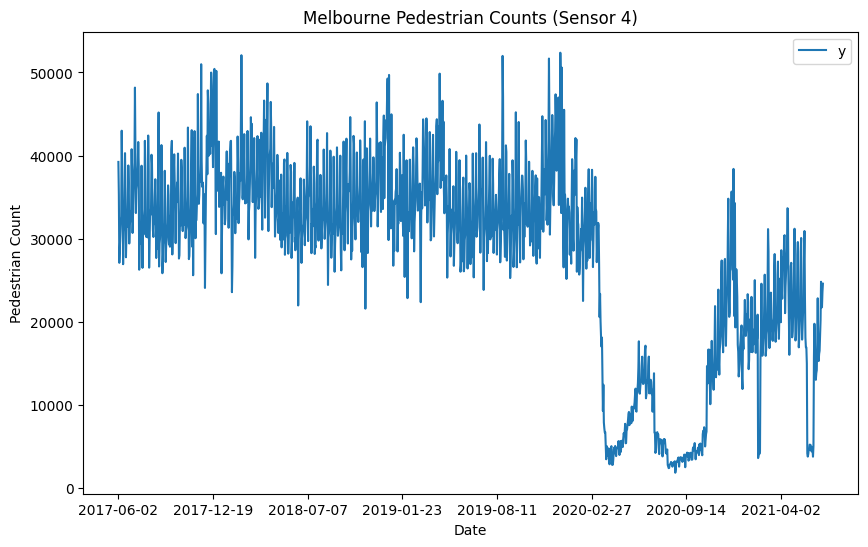

In [ ]:
# Plot the time series
df.set_index('ds').plot(title='Melbourne Pedestrian Counts (Sensor 4)',
                        ylabel='Pedestrian Count',
                        xlabel='Date')

The plot immediately reveals the dramatic impact of Melbourne's two major lockdowns in 2020. A standard forecasting model would struggle to distinguish these anomalous dips from the natural trend and seasonality of the data.

## 2\. The Baseline: Default Prophet Forecast

Let's see how a default Prophet model handles this raw data. This will serve as our baseline.

DEBUG:cmdstanpy:input tempfile: /tmp/tmptggqpn98/2ih6_yay.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmptggqpn98/6b9l88cy.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=5527', 'data', 'file=/tmp/tmptggqpn98/2ih6_yay.json', 'init=/tmp/tmptggqpn98/6b9l88cy.json', 'output', 'file=/tmp/tmptggqpn98/prophet_modelgr7bpxtp/prophet_model-20251101145043.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
14:50:43 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
14:50:43 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Text(65.84722222222221, 0.5, 'Pedestrian Count')

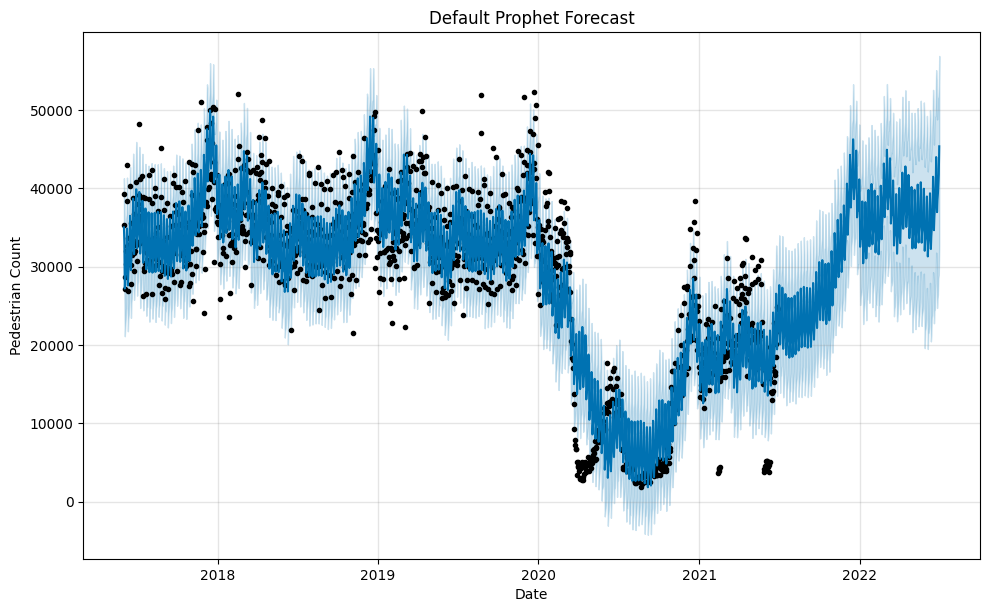

In [ ]:
# Initialize and fit the default model
m = Prophet()
m.fit(df)

# Create a future dataframe for forecasting 1 year ahead
future = m.make_future_dataframe(periods=366)

# Generate the forecast
forecast = m.predict(future)

# Plot the forecast
m.plot(forecast)
plt.title('Default Prophet Forecast')
plt.xlabel('Date')
plt.ylabel('Pedestrian Count')

The black dots are our available data points, while the blue line is our prediction.

Let's examine the components to see *what* the model learned.

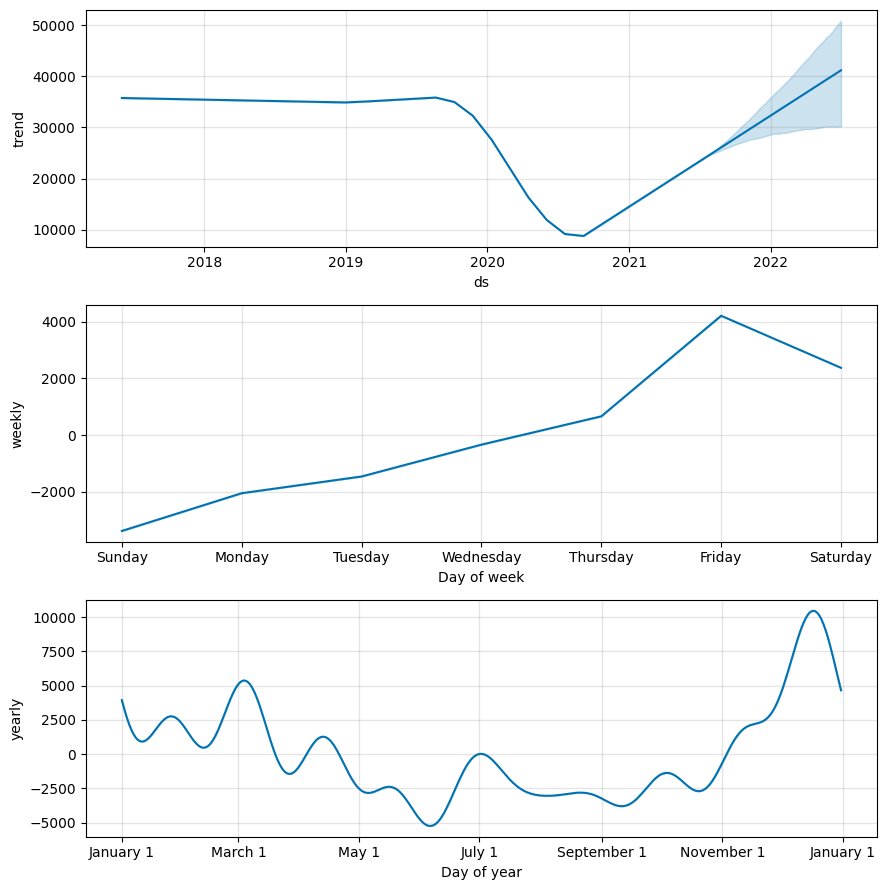

In [ ]:
# Plot the forecast components
components = m.plot_components(forecast)

**Analysis & Diagnosis:** 🧐

The default model has made a critical error. It has incorporated the sharp lockdown dips and subsequent rebounds into the **trend component `g(t)`**. This is incorrect because lockdowns are not part of a long-term growth pattern.

**This error leads to two problems:**

1.  The historical trend is distorted and doesn't reflect the true underlying pattern.
2.  The forecast is wildly optimistic and has a massive uncertainty interval (the light blue shade), as the model assumes these huge trend shifts could happen again.

We need to tell the model that these dips are special events.

## 3\. Isolating Shocks with Holidays

A better approach is to explicitly model these lockdown periods using the **holidays component `h(t)`**. This isolates their effect from the trend, treating them as explainable, one-off events.

📚 **Learn More:** [Prophet Docs: Holidays and Special Events](https://facebook.github.io/prophet/docs/seasonality,_holiday_effects,_and_regressors.html#modeling-holidays-and-special-events)

We'll create a DataFrame specifying the start and duration of each lockdown.

DEBUG:cmdstanpy:input tempfile: /tmp/tmptggqpn98/fupq7_x0.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmptggqpn98/kjdet0e8.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=86837', 'data', 'file=/tmp/tmptggqpn98/fupq7_x0.json', 'init=/tmp/tmptggqpn98/kjdet0e8.json', 'output', 'file=/tmp/tmptggqpn98/prophet_model1xyxn5vg/prophet_model-20251101145048.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
14:50:48 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
14:50:49 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


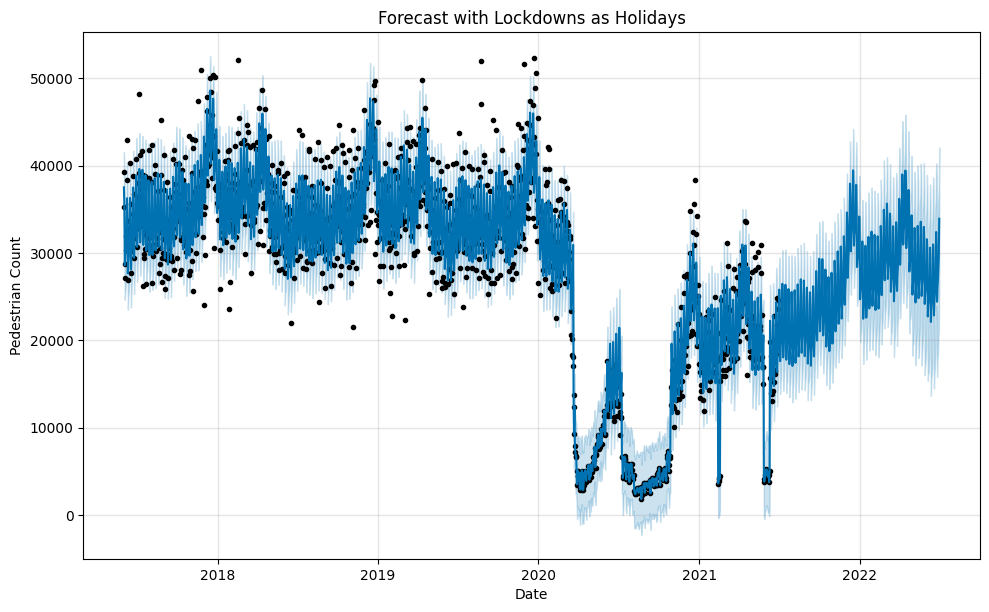

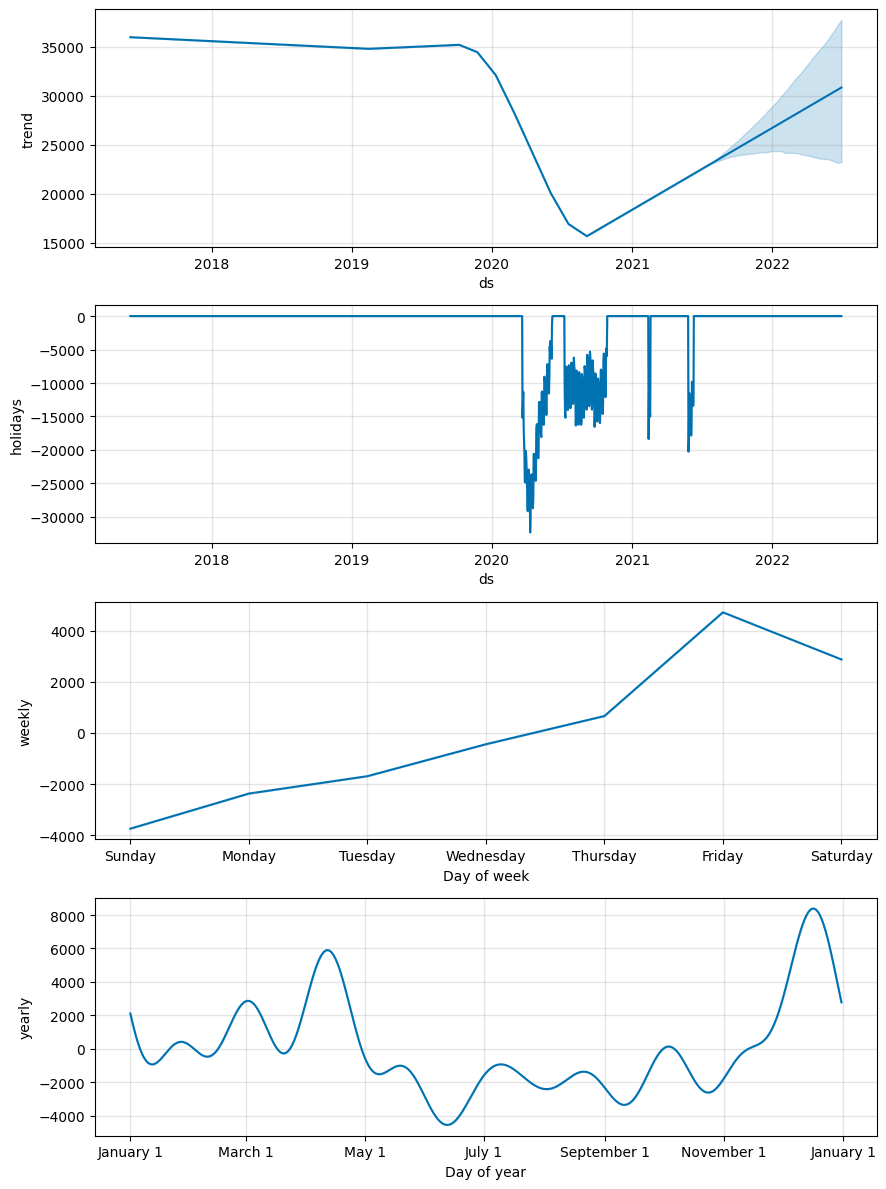

In [ ]:
# Create a dataframe of lockdown events
lockdowns = pd.DataFrame([
    {'holiday': 'lockdown_1', 'ds': '2020-03-21', 'lower_window': 0, 'ds_upper': '2020-06-06'},
    {'holiday': 'lockdown_2', 'ds': '2020-07-09', 'lower_window': 0, 'ds_upper': '2020-10-27'},
    {'holiday': 'lockdown_3', 'ds': '2021-02-13', 'lower_window': 0, 'ds_upper': '2021-02-17'},
    {'holiday': 'lockdown_4', 'ds': '2021-05-28', 'lower_window': 0, 'ds_upper': '2021-06-10'},
])

# Convert date strings to datetime objects
for t_col in ['ds', 'ds_upper']:
    lockdowns[t_col] = pd.to_datetime(lockdowns[t_col])

# 'upper_window' is the number of days the event lasts after the start date 'ds'
lockdowns['upper_window'] = (lockdowns['ds_upper'] - lockdowns['ds']).dt.days

# Initialize Prophet with our custom holidays
m2 = Prophet(holidays=lockdowns)
m2.fit(df)

# Make a new forecast
future2 = m2.make_future_dataframe(periods=366)
forecast2 = m2.predict(future2)

# Plot the new forecast and its components
m2.plot(forecast2)
plt.title('Forecast with Lockdowns as Holidays')
plt.xlabel('Date')
plt.ylabel('Pedestrian Count')
components = m2.plot_components(forecast2)

**Analysis & Improvement:**

This is a great improvement\!

  * The new **holidays component** now shows large, negative effects corresponding exactly to the lockdown periods. We have successfully isolated the shock.
  * The **trend component `g(t)`** is now much smoother and more realistic. It reflects a gentle decline followed by a slow recovery, which is a much more plausible long-term pattern.
  * The future forecast is more conservative and has a tighter uncertainty interval.

## 4\. Tuning Trend Flexibility

Prophet models the trend `g(t)` using a **piecewise linear model**. It automatically detects changepoints, points where the trend is allowed to change its slope. The flexibility of this trend is controlled by a regularization parameter called `changepoint_prior_scale`.

  * **Low `changepoint_prior_scale`** (default is 0.05): the trend is rigid (underfitting risk).
  * **High `changepoint_prior_scale`**: the trend is highly flexible (overfitting risk).

📚 **Learn More:** [Prophet Docs: Trend Changepoints](https://facebook.github.io/prophet/docs/trend_changepoints.html)

Let's visualize the changepoints our model `m2` detected.

Text(0.5, 1.0, 'Detected Changepoints in Model 2')

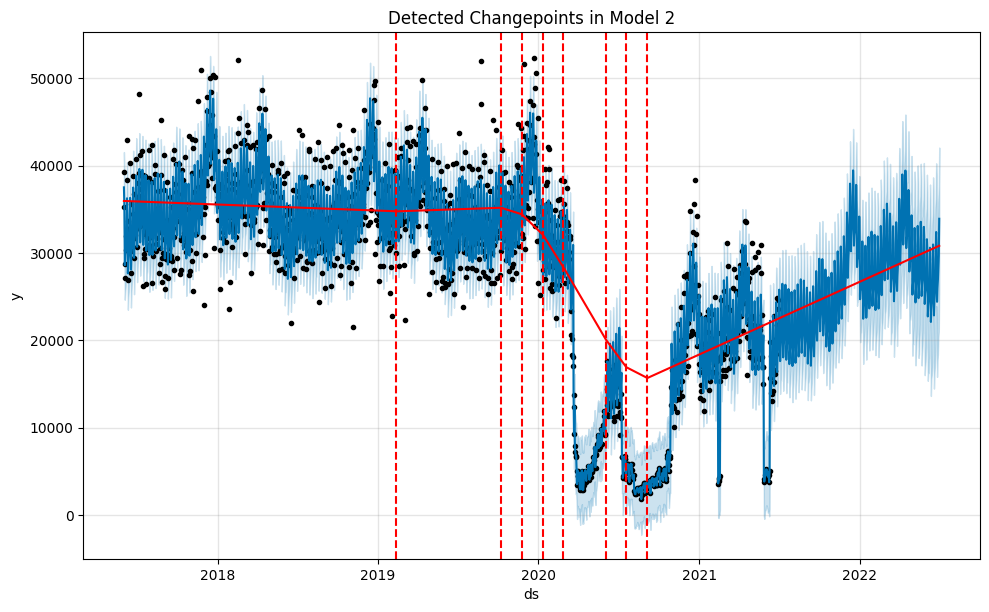

In [ ]:
from prophet.plot import add_changepoints_to_plot

# Plot the forecast with the detected changepoints (red dashed lines)
fig = m2.plot(forecast2)
a = add_changepoints_to_plot(fig.gca(), m2, forecast2)
plt.title("Detected Changepoints in Model 2")

The detected changepoints seem reasonable. However, what if we believe the post-COVID period is more dynamic and we want the model to be more responsive to recent changes? We can increase the flexibility by raising `changepoint_prior_scale` and specifying more potential changepoints in the volatile period.

DEBUG:cmdstanpy:input tempfile: /tmp/tmptggqpn98/afz0f75e.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmptggqpn98/7gbezu7k.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=68474', 'data', 'file=/tmp/tmptggqpn98/afz0f75e.json', 'init=/tmp/tmptggqpn98/7gbezu7k.json', 'output', 'file=/tmp/tmptggqpn98/prophet_modelsfsgsyz6/prophet_model-20251101145052.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
14:50:52 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
14:50:55 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Text(0.5, 1.0, 'Forecast with a More Flexible Trend')

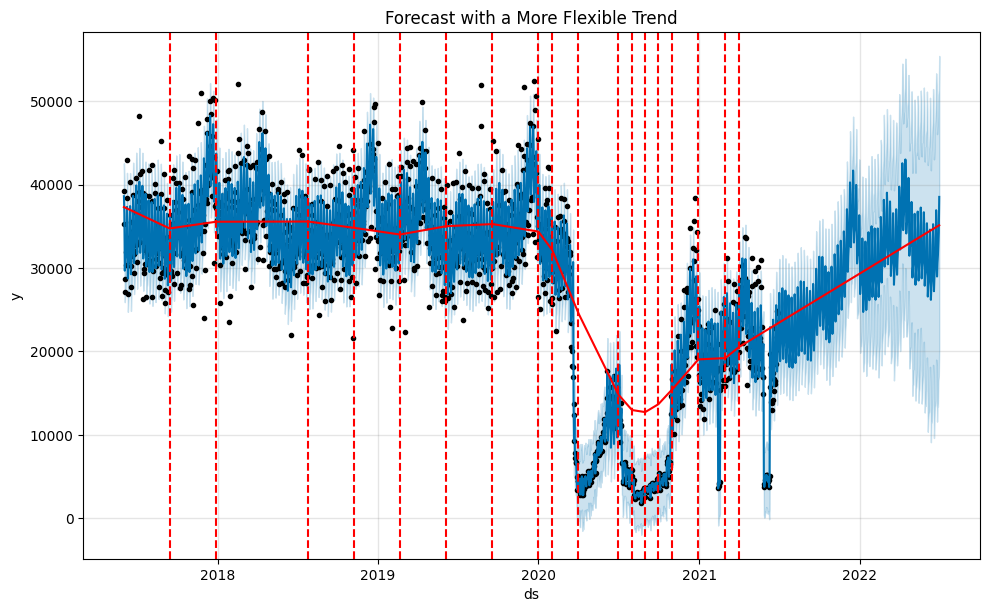

In [ ]:
# Define more potential changepoints, concentrating them during the COVID period
m3_changepoints = (
    pd.date_range('2017-06-02', '2020-01-01', periods=10).date.tolist() +
    pd.date_range('2020-02-01', '2021-04-01', periods=15).date.tolist()
)

# Initialize a more flexible model
m3 = Prophet(
    holidays=lockdowns,
    changepoints=m3_changepoints,
    changepoint_prior_scale=1.0  # Increase flexibility significantly from 0.05
)
m3.fit(df)

# Make and plot the forecast
forecast3 = m3.predict(future2)
fig = m3.plot(forecast3)
a = add_changepoints_to_plot(fig.gca(), m3, forecast3)
plt.title("Forecast with a More Flexible Trend")

**Analysis & Trade-offs:**

This model's trend is much "spikier" as it fits more closely to the post-lockdown fluctuations. The key result is the **dramatically wider uncertainty interval**. By making the trend more flexible, we are acknowledging that the future is more uncertain given the recent volatility. This model might not produce a better point forecast, but it gives a more honest representation of potential future outcomes.

## 5\. Modeling Changes in Seasonality

Did the pandemic fundamentally change weekly routines? With widespread work-from-home, perhaps Friday is no longer the peak day for city foot traffic. We can model this structural break using **conditional seasonalities**.

Prophet models seasonality `s(t)` using a **Fourier series**, which is a way of combining sine and cosine curves to model any periodic pattern. Conditional seasonality allows us to fit *different* Fourier series based on a condition—in our case, whether a date is pre- or post-COVID.

📚 **Learn More:** [Prophet Docs: Conditional Seasonalities](https://facebook.github.io/prophet/docs/seasonality,_holiday_effects,_and_regressors.html#seasonalities-that-depend-on-other-factors)

First, we add boolean columns to our data to define the two periods.

In [ ]:
# Create a copy of the dataframe
df2 = df.copy()

# Add boolean flags for the two periods, using the first lockdown date as the cutoff
df2['pre_covid'] = pd.to_datetime(df2['ds']) < pd.to_datetime('2020-03-21')
df2['post_covid'] = ~df2['pre_covid']

Now, we build a model with two distinct weekly seasonalities.

DEBUG:cmdstanpy:input tempfile: /tmp/tmptggqpn98/5qvwfuj6.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmptggqpn98/dqa8yu3o.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=61166', 'data', 'file=/tmp/tmptggqpn98/5qvwfuj6.json', 'init=/tmp/tmptggqpn98/dqa8yu3o.json', 'output', 'file=/tmp/tmptggqpn98/prophet_modelr6cewop4/prophet_model-20251101145057.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
14:50:57 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
14:50:58 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


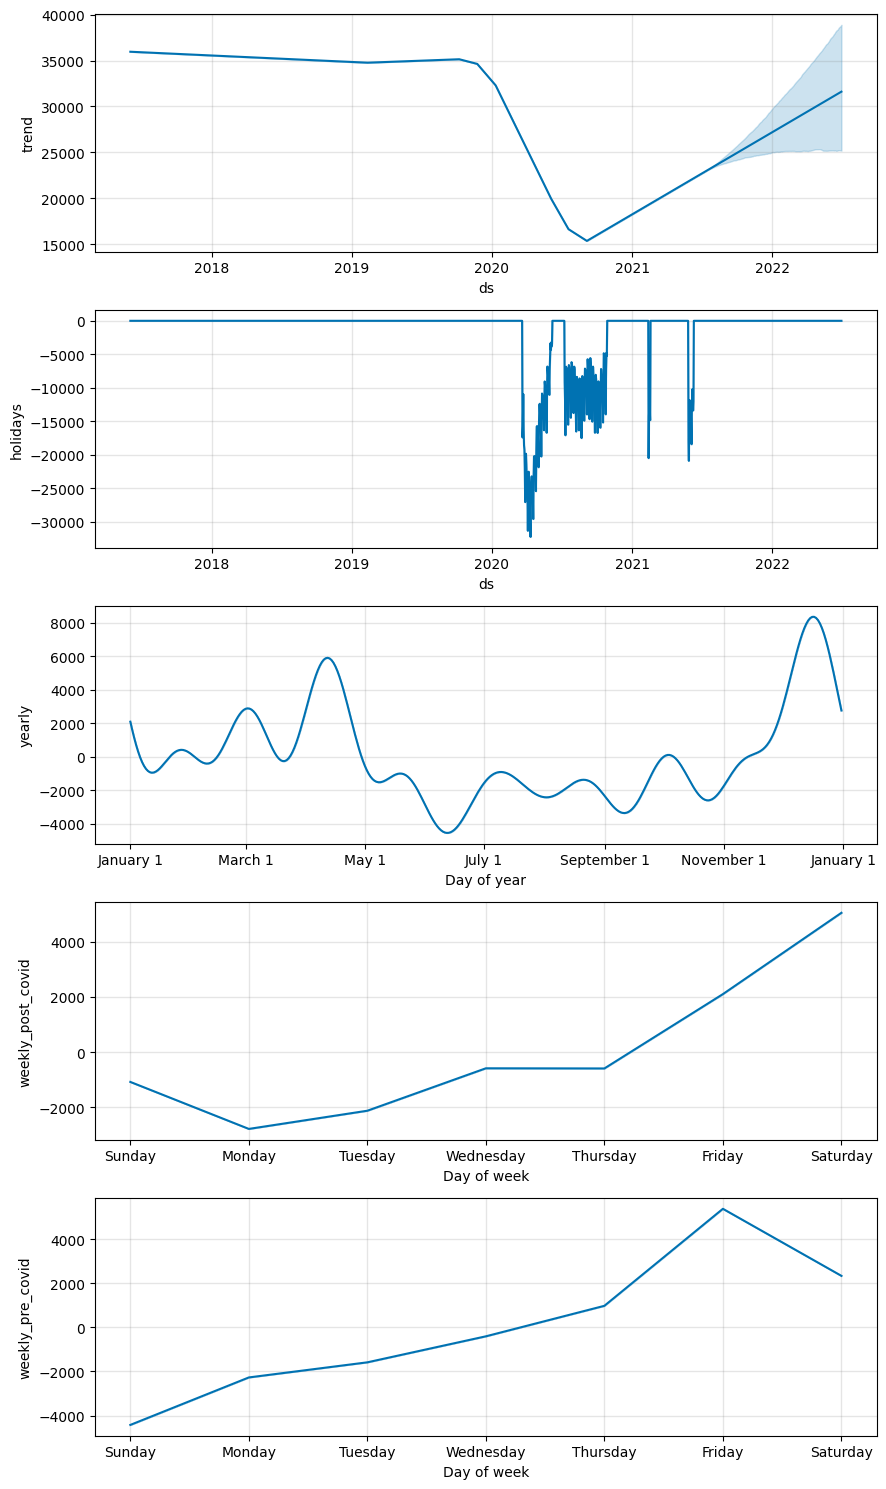

In [ ]:
# Initialize model with default weekly seasonality turned OFF
m4 = Prophet(holidays=lockdowns, weekly_seasonality=False)

# Add a weekly seasonality component that only applies to pre-COVID dates
m4.add_seasonality(
    name='weekly_pre_covid',
    period=7,
    fourier_order=3,  # Standard complexity for weekly patterns
    condition_name='pre_covid',
)

# Add another weekly seasonality component that only applies to post-COVID dates
m4.add_seasonality(
    name='weekly_post_covid',
    period=7,
    fourier_order=3,
    condition_name='post_covid',
)

# Fit the model on the data with the new boolean columns
m4.fit(df2)

# IMPORTANT: Add the condition columns to the future dataframe as well!
future4 = m4.make_future_dataframe(periods=366)
future4['pre_covid'] = pd.to_datetime(future4['ds']) < pd.to_datetime('2020-03-21')
future4['post_covid'] = ~future4['pre_covid']

# Make and plot the forecast components
forecast4 = m4.predict(future4)
components = m4.plot_components(forecast4)

**Analysis & Insights:** 💡

This reveals a fascinating behavioral insight\!

  * **Pre-COVID:** The `weekly_pre_covid` component shows that pedestrian activity clearly peaked on **Fridays**.
  * **Post-COVID:** The `weekly_post_covid` component shows the peak has shifted to **Saturdays**.

This is a powerful demonstration of how conditional seasonalities can uncover and model fundamental changes in behavior, leading to more accurate and insightful forecasts.

## Conclusion & Next Steps

By moving beyond the defaults, we've transformed a naive baseline model into a sophisticated forecasting tool that understands the nuances of a post-pandemic world. You now have a framework for tackling complex time series data with structural breaks.

**Key Techniques Recap:**

  * **Holidays `h(t)`:** Isolate large, one-off events to protect the integrity of the trend.
  * **Trend `g(t)`:** Tune `changepoint_prior_scale` to control the trade-off between trend flexibility and overfitting.
  * **Seasonality `s(t)`:** Use `add_seasonality` with conditions to model changes in periodic behavior.

Forecasting in a volatile environment is an ongoing process. Remember to constantly re-evaluate your models as new data becomes available and clearly communicate the uncertainty inherent in your predictions.